# European Area Banks: Financial Structure and Performance (2006 - 2024)
**Dataset:** Bankfocus ~100 EA SI

## 0. Setup and Data Loading

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import warnings
from openpyxl import load_workbook
from matplotlib.lines import Line2D
import os


In [41]:
warnings.filterwarnings("ignore")
DATA_PATH = "Case1_Dataset.xlsx"
df = pd.read_excel(DATA_PATH, sheet_name="Results")

def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s.lower() in ("n.a.", "n.a", "na", "nan", "", "-", "none"):
        return np.nan
    s = s.replace(' ', '')
    if s.count('.') > 1:
        s = s.replace('.', '')
    elif ',' in s and '.' not in s:
        s = s.replace(',', '.')
    try:
        return float(s)
    except:
        return np.nan

for col in df.columns:
    if col != 'Company name Latin alphabet':
        df[col] = df[col].apply(clean_numeric)


## 1. Balance Sheet Composition (2016 – 2018 – 2024)

Grouped bar chart: asset side (% of Total Assets) and liability side (% of Total Liabilities & Equity).
Three reference years capture pre-pandemic, pandemic-era, and current structure.

In [43]:
YEARS = [2016, 2018, 2024]
COLORS = {2016:"#F5A623", 2018:"#C0392B", 2024:"#1F3D7A"}

In [44]:
def agg(base, year):
    cols = [c for c in df.columns if base in c and str(year) in c]
    if not cols:
        return np.nan
    s = df[cols[0]]
    return s.sum(skipna=True)


In [45]:
asset_labels = [
    'Total loans\nand advances',
    'Securities and\ninstruments',
    'Cash & central bank\nbalances',
    'Other\nassets',
]

liab_labels = [
    'Household and\ncorporate deposits',
    'Wholesale market\nfunding',
    'Central bank\nfunding',
    'Equity',
    'Other\nliabilities',
]

asset_vals = {y: [] for y in YEARS}
liab_vals = {y: [] for y in YEARS}

for y in YEARS:
    ta = agg("Total assets EUR", y)
    loans = agg("Gross loans & advances to customers EUR", y)
    sec = agg('Securities and Investments EUR', y)
    cash = agg('Cash & balances with central banks EUR', y)
    other_ea = agg('Other earning assets EUR', y)
    other_a = ta - loans - sec - cash - other_ea
    deposits = agg('Total customer deposits EUR', y)
    wholesale = agg('Wholesale funding EUR', y)
    equity = agg('Total equity EUR', y)
    cb = agg('Mandatory reserve deposits with central banks EUR', y)
    other_l = ta - deposits - wholesale - equity - cb


    pct = lambda v: round(v / ta * 100, 2)
    asset_vals[y] = [pct(loans), pct(sec), pct(cash), pct(other_a)]
    liab_vals[y]  = [pct(deposits), pct(wholesale), pct(cb), pct(equity), pct(other_l)]

Text(0.5, 1.09, "BS' Composition")

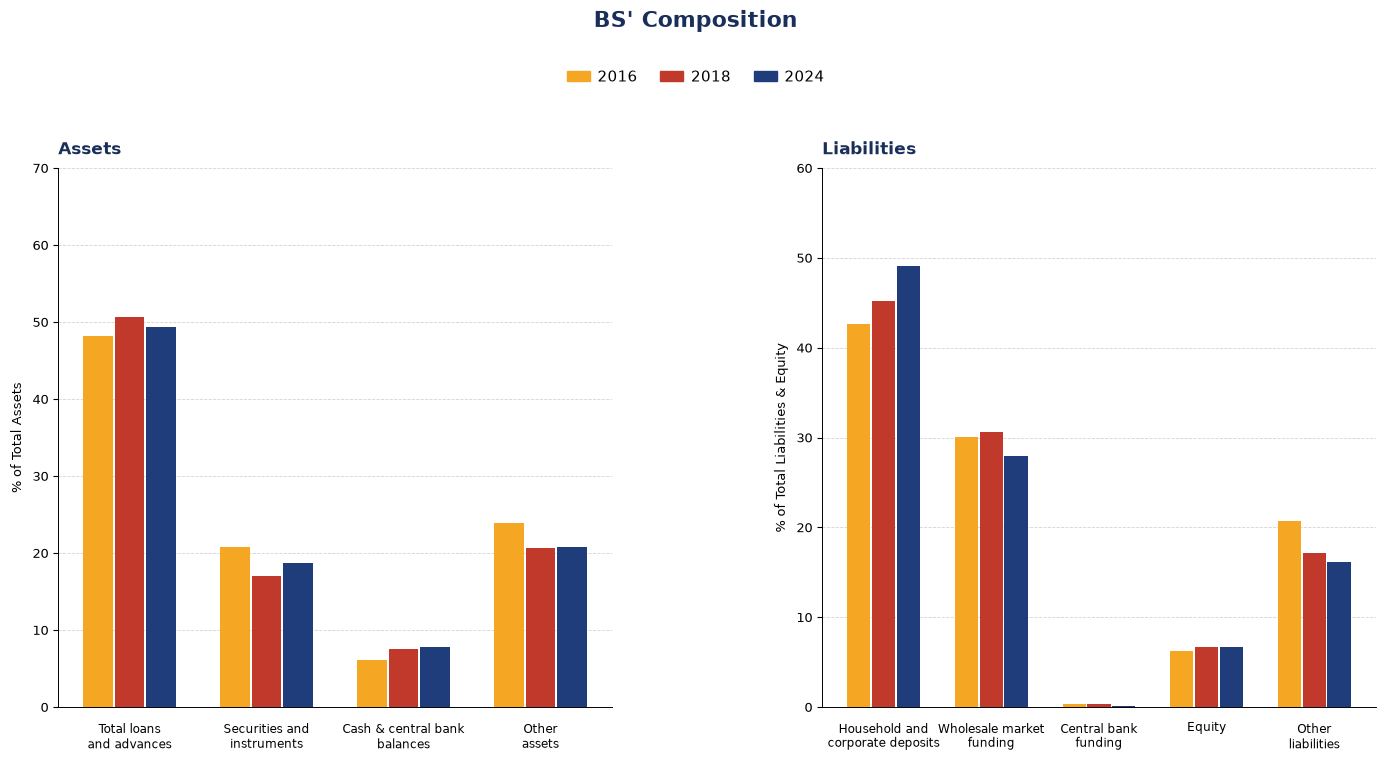

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'wspace': 0.38})
fig.patch.set_facecolor('white')

BAR_W = 0.23
OFFSETS = np.array([-BAR_W, 0, BAR_W])

def draw_panel(ax, labels, vals_dict, title, ylabel, ymax):
    x = np.arange(len(labels))
    for (year, vals), off in zip(vals_dict.items(), OFFSETS):
        ax.bar(x + off, vals, BAR_W - 0.015, color=COLORS[year], zorder=3, linewidth=0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5, ha='center', linespacing=1.3)
    ax.tick_params(axis='x', bottom=False, pad=6)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.grid(axis='y', which='major', linestyle='--', linewidth=0.6, alpha=0.55, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1A2E5A', pad=10, loc='left')
    ax.set_ylabel(ylabel, fontsize=9.5, labelpad=6)

draw_panel(ax1, asset_labels, asset_vals,
           title='Assets',
           ylabel='% of Total Assets',
           ymax=70)

draw_panel(ax2, liab_labels, liab_vals,
           title='Liabilities',
           ylabel='% of Total Liabilities & Equity',
           ymax=60)

patches = [mpatches.Patch(color=COLORS[y], label=str(y)) for y in YEARS]
fig.legend(handles=patches, loc='upper center', ncol=3, fontsize=11,
           frameon=False, bbox_to_anchor=(0.5, 1.04),
           handlelength=1.5, handletextpad=0.5, columnspacing=1.5)
fig.text(0.5, 1.09, "BS' Composition", ha='center', va='center',
         fontsize=16, fontweight='bold', color='#1A2E5A')



## 2. Capital Ratios and RWA (2017–2024)

Dual axis chart: total RWA (bars, left axis) vs. median CET1 / Tier 1 / Total Capital ratios (lines, right axis).

**Methodological note — two different samples:**
- RWA bars use a balanced panel (banks with at most 1 missing year, gaps filled by linear interpolation).
- Capital ratios use a *strict annual sample* (a bank is included in year $t$ only if all four metrics — RWA, TCR, Tier 1, CET1 — are non-null and RWA > 0). Median is preferred over mean to limit outlier influence.

Final data:
 year       rwa_bn      cet1  tier1      tcr
 2017 2214143.9910 17.007905  17.20 18.10000
 2018 2208904.1780 16.861795  17.20 18.50000
 2019 2339789.6800 18.481183  18.70 20.06000
 2020 2302117.7595 19.215265  19.71 21.27000
 2021 2306568.8890 17.671231  20.02 20.99500
 2022 2434027.1660 18.293042  19.84 20.41000
 2023 2453452.1370 21.072540  22.07 22.77000
 2024 2583565.5700 22.774032  23.09 23.78685


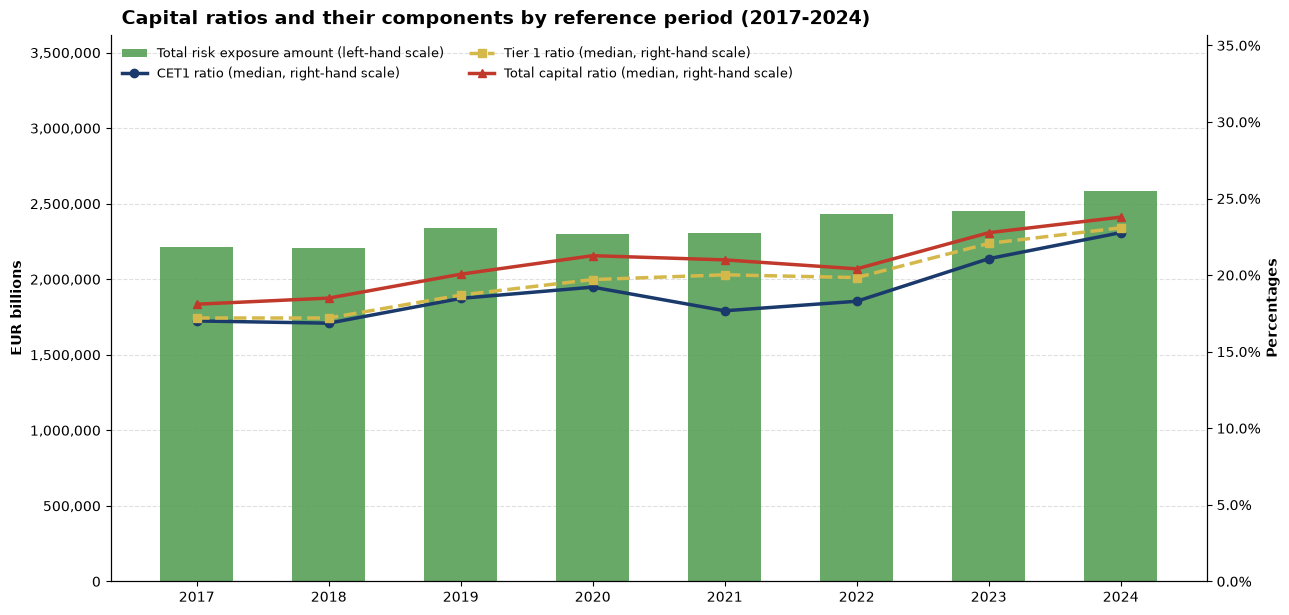

In [ ]:
years = list(range(2017, 2025))

rwa_cols_list = [f"Total risk-weighted assets (RWAs) - Fully loaded (highest) EUR {yr}" for yr in years]
df_rwa_raw = df[rwa_cols_list]

mask_tollerante = df_rwa_raw.isna().sum(axis=1) <= 1
df_rwa_filled = df_rwa_raw[mask_tollerante].interpolate(method='linear', axis=1, limit_direction='both')

rwa_agg_stable = (df_rwa_filled.sum() / 1e6).tolist()

cet1_agg, tier1_agg, tcr_agg = [], [], []

for yr in years:
    rwa_col = f"Total risk-weighted assets (RWAs) - Fully loaded (highest) EUR {yr}"
    tcr_col = f"Total capital adequacy ratio {yr}"
    t1_col  = f"Tier 1 ratio {yr}"
    label   = f"Common Equity / Core Tier 1 (CET1) (as reported) EUR {yr}"

    indices = [i for i, h in enumerate(df.columns) if h == label]
    idx_cet1 = indices[1] if len(indices) > 1 else indices[0]
    
    rwa_curr  = df[rwa_col]
    tcr_curr  = df[tcr_col]
    t1_curr   = df[t1_col]
    cet1_curr = df.iloc[:, idx_cet1]

    mask_rigida = rwa_curr.notna() & tcr_curr.notna() & t1_curr.notna() & cet1_curr.notna() & (rwa_curr > 0)

    # median (better than mean, to deal with outliers)
    cet1_agg.append((cet1_curr[mask_rigida] / rwa_curr[mask_rigida] * 100).median())
    tier1_agg.append(t1_curr[mask_rigida].median())
    tcr_agg.append(tcr_curr[mask_rigida].median())

# final Dataframe
agg = pd.DataFrame({
    "year"   : years,
    "rwa_bn" : rwa_agg_stable,
    "cet1"   : cet1_agg,
    "tier1"  : tier1_agg,
    "tcr"    : tcr_agg,
})

print("Final data:")
print(agg.to_string(index=False))

# Graph
COLOR_BAR   = "#4e9a4e"
COLOR_CET1  = "#1a3a6b"
COLOR_TIER1 = "#d4b84a"
COLOR_TCR   = "#c0392b"

fig, ax1 = plt.subplots(figsize=(13, 6))

# RWA bars
ax1.bar(agg["year"], agg["rwa_bn"], width=0.55, color=COLOR_BAR, alpha=0.85,
        label="Total risk exposure amount (left-hand scale)", zorder=2)
ax1.set_ylabel("EUR billions", fontsize=10, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.set_ylim(0, agg["rwa_bn"].max() * 1.4)
ax1.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax1.set_axisbelow(True)

# Ratios lines
ax2 = ax1.twinx()
ax2.plot(agg["year"], agg["cet1"],  color=COLOR_CET1,  linewidth=2.5,
         marker="o", markersize=6, label="CET1 ratio (median, right-hand scale)")
ax2.plot(agg["year"], agg["tier1"], color=COLOR_TIER1, linewidth=2.5,
         marker="s", markersize=6, linestyle="--", label="Tier 1 ratio (median, right-hand scale)")
ax2.plot(agg["year"], agg["tcr"],   color=COLOR_TCR,   linewidth=2.5,
         marker="^", markersize=6, label="Total capital ratio (median, right-hand scale)")

ax2.set_ylabel("Percentages", fontsize=10, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

max_val = max(agg["tcr"].max(), agg["cet1"].max())
ax2.set_ylim(0, max_val * 1.5)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.set_xticks(years)

fig.text(0.01, 1.02, "Capital ratios and their components by reference period (2017-2024)",
         fontsize=14, fontweight="bold", ha="left", transform=ax1.transAxes)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
            loc="upper left", fontsize=9, frameon=False, ncol=2)

plt.tight_layout()
plt.show()


## 3. Non-Performing Loans (2015–2024)

Stacked bar chart (performing + non performing loans in EUR bn) with NPL ratio line on secondary axis.

**Imputation logic (2-of-3 rule):**
Given NPL, Gross Loans, NPL Ratio, if exactly one is missing and the other two are available, the missing value is recovered algebraically. Rows with fewer than two available values are dropped.

In [48]:
#the capital ratios use a dynamic annual sample, including a bank only if all four key metrics are present for that specific year

sample_consistency_check = []

for yr in years:
    # Banks for RWA bars
    n_banks_rwa = mask_tollerante.sum()

    # Banks for ratios
    rwa_curr  = df[f"Total risk-weighted assets (RWAs) - Fully loaded (highest) EUR {yr}"]
    tcr_curr  = df[f"Total capital adequacy ratio {yr}"]
    t1_curr   = df[f"Tier 1 ratio {yr}"]

    label = f"Common Equity / Core Tier 1 (CET1) (as reported) EUR {yr}"
    indices = [i for i, h in enumerate(df.columns) if h == label]
    idx_cet1 = indices[1] if len(indices) > 1 else indices[0]
    cet1_curr = df.iloc[:, idx_cet1]

    # Strict mask for ratios
    mask_rigida = rwa_curr.notna() & tcr_curr.notna() & t1_curr.notna() & cet1_curr.notna() & (rwa_curr > 0)
    n_banks_ratio = mask_rigida.sum()

    sample_consistency_check.append({
        "Year": yr,
        "RWA_Bar_Banks": n_banks_rwa,
        "Ratio_Median_Banks": n_banks_ratio,
        "Difference": n_banks_rwa - n_banks_ratio
    })

# Final table
df_check = pd.DataFrame(sample_consistency_check)

print("--- SAMPLE CONSISTENCY REPORT ---")
print("RWA_Bar_Banks: quasi balanced sample (max 1 missing value over the period)")
print("Ratio_Median_Banks: Strict annual sample (all 4 metrics present for the specific year)")
print("-" * 65)
print(df_check.to_string(index=False))

# Stability/Coverage
avg_coverage_pct = (df_check["Ratio_Median_Banks"].mean() / len(df)) * 100
print(f"\nAverage coverage of the original dataset: {avg_coverage_pct:.1f}%")


--- SAMPLE CONSISTENCY REPORT ---
RWA_Bar_Banks: quasi balanced sample (max 1 missing value over the period)
Ratio_Median_Banks: Strict annual sample (all 4 metrics present for the specific year)
-----------------------------------------------------------------
 Year  RWA_Bar_Banks  Ratio_Median_Banks  Difference
 2017             44                  44           0
 2018             44                  55         -11
 2019             44                  55         -11
 2020             44                  54         -10
 2021             44                  56         -12
 2022             44                  58         -14
 2023             44                  55         -11
 2024             44                  54         -10

Average coverage of the original dataset: 48.5%


 year  n_banks     npl_bn     perf_bn  npl_ratio  skipped  imp_npl  imp_ratio  imp_gross
 2015       44 442.324488 5035.903355   8.074226       67       21          8          0
 2016       49 418.452116 5156.471164   7.505971       62       27          8          0
 2017       57 332.405531 4940.642737   6.303859       54       35          8          0
 2018       67 295.977061 5983.558825   4.713359       44       43          6          0
 2019       66 263.587107 6346.640942   3.987565       45       42          5          0
 2020       75 250.647629 6533.538554   3.694587       36       50          7          0
 2021       71 213.465889 6831.096368   3.030222       40       47          7          0
 2022       75 224.440842 7139.204717   3.047958       36       51          4          0
 2023       81 249.977979 7172.822917   3.367704       30       57          5          0
 2024       79 260.002733 7301.379321   3.438561       32       57          4          0


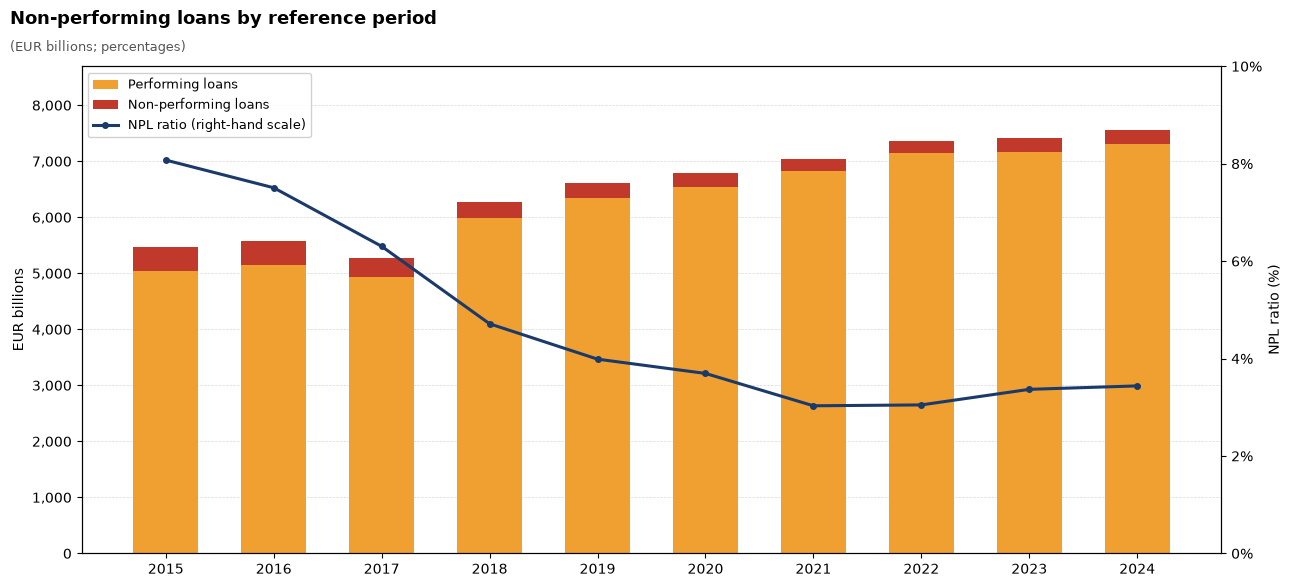

In [ ]:
years = list(range(2015, 2025))
records = []

for year in years:
    npl_col   = f"Impaired / Non-performing loans to customers EUR {year}"
    gross_col = f"Gross loans & advances to customers EUR {year}"
    ratio_col = f"NPL ratio (as reported) {year}"

    df_yr = df[[npl_col, gross_col, ratio_col]].copy()
    
    # Normalise ratio to decimal 
    mask_ratio = (df_yr[ratio_col].notna()) & (df_yr[ratio_col] > 1)
    df_yr.loc[mask_ratio, ratio_col] = df_yr.loc[mask_ratio, ratio_col] / 100.0

    # Impute missing variables
    imp_npl_mask = df_yr[npl_col].isna() & df_yr[gross_col].notna() & df_yr[ratio_col].notna()
    df_yr.loc[imp_npl_mask, npl_col] = df_yr.loc[imp_npl_mask, gross_col] * df_yr.loc[imp_npl_mask, ratio_col]
    
    imp_ratio_mask = df_yr[ratio_col].isna() & df_yr[npl_col].notna() & df_yr[gross_col].notna() & (df_yr[gross_col] > 0)
    df_yr.loc[imp_ratio_mask, ratio_col] = df_yr.loc[imp_ratio_mask, npl_col] / df_yr.loc[imp_ratio_mask, gross_col]
    
    imp_gross_mask = df_yr[gross_col].isna() & df_yr[npl_col].notna() & df_yr[ratio_col].notna() & (df_yr[ratio_col] > 0)
    df_yr.loc[imp_gross_mask, gross_col] = df_yr.loc[imp_gross_mask, npl_col] / df_yr.loc[imp_gross_mask, ratio_col]

    # Skip if we still lack NPL or Gross
    valid_mask = df_yr[npl_col].notna() & df_yr[gross_col].notna() & (df_yr[gross_col] > 0)
    df_valid = df_yr[valid_mask]
    
    skipped = len(df_yr) - len(df_valid)
    total_npl = df_valid[npl_col].sum()
    total_gross = df_valid[gross_col].sum()
    n = len(df_valid)

    agg_ratio  = total_npl / total_gross if total_gross > 0 else np.nan
    performing = total_gross - total_npl

    records.append({
        "year":       year,
        "npl_bn":     total_npl   / 1e9,
        "perf_bn":    performing  / 1e9,
        "total_bn":   total_gross / 1e9,
        "npl_ratio":  agg_ratio * 100,
        "n_banks":    n,
        "skipped":    skipped,
        "imp_npl":    imp_npl_mask.sum(),
        "imp_ratio":  imp_ratio_mask.sum(),
        "imp_gross":  imp_gross_mask.sum(),
    })

result = pd.DataFrame(records)
print(result[["year","n_banks","npl_bn","perf_bn","npl_ratio","skipped",
              "imp_npl","imp_ratio","imp_gross"]].to_string(index=False))

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

x      = np.arange(len(years))
width  = 0.6
color_perf = "#f0a030"
color_npl  = "#c0392b"
color_line = "#1a3a6b"

bars_perf = ax1.bar(x, result["perf_bn"], width, label="Performing loans",      color=color_perf)
bars_npl  = ax1.bar(x, result["npl_bn"],  width, label="Non-performing loans",   color=color_npl,
                    bottom=result["perf_bn"])

line, = ax2.plot(x, result["npl_ratio"], color=color_line, linewidth=2.2,
                 marker="o", markersize=4, label="NPL ratio (right-hand scale)")

ax1.set_xticks(x)
ax1.set_xticklabels([str(y) for y in years], fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.set_ylabel("EUR billions", fontsize=10)
ax1.set_ylim(0, result["total_bn"].max() * 1.15)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax2.set_ylabel("NPL ratio (%)", fontsize=10)
ax2.set_ylim(0, 10)

ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)

handles = [bars_perf, bars_npl, line]
ax1.legend(handles, [h.get_label() for h in handles], loc="upper left", fontsize=9, framealpha=0.9)

fig.text(0.01, 0.97, "Non-performing loans by reference period", fontsize=13, fontweight="bold", va="top")
fig.text(0.01, 0.92, "(EUR billions; percentages)", fontsize=9, color="#555", va="top")

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()


## 4. Profitability — ROAE (2016–2024)

Two complementary views:
1. **Quartile trends:** banks grouped into ROAE quartiles each year; mean ROAE per quartile plotted over time.
2. **Distribution summary:** median, asset-weighted average, and interquartile range (Q1–Q3) by year.

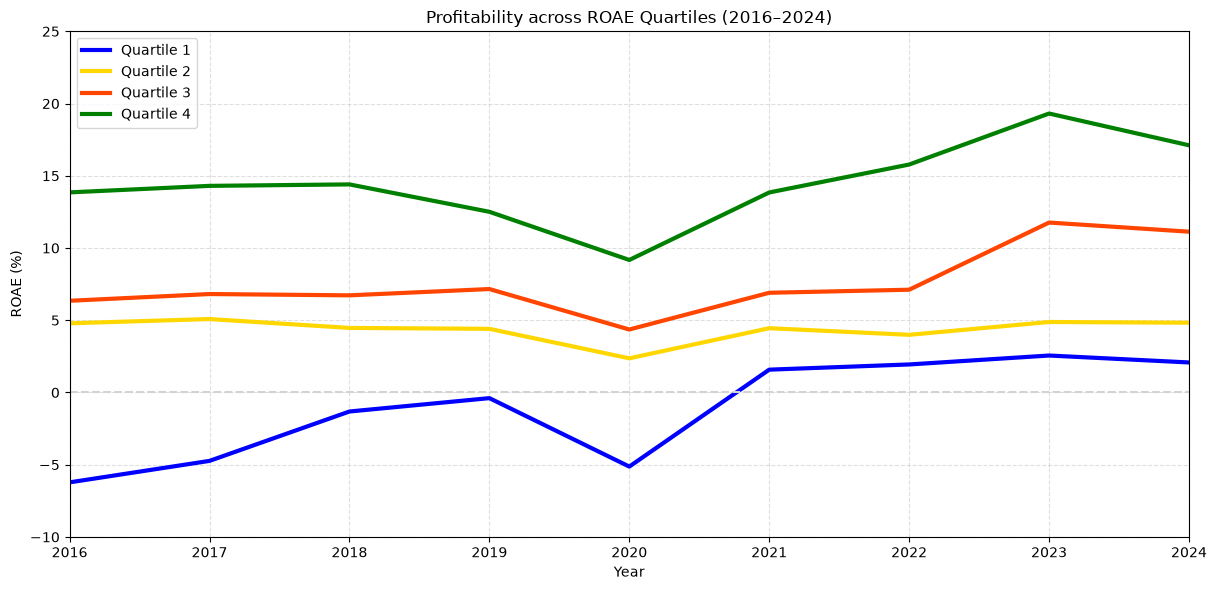

In [ ]:
# This chart groups banks into quartiles based on their ROAE distribution for each year.

years = list(range(2016, 2025))
roae_cols = {year: f"Return on average equity (ROAE) {year}" for year in years}

quartile_means = {"Q1": [], "Q2": [], "Q3": [], "Q4": []}

for year in years:
    col = roae_cols[year]

    data = df[col].dropna()

    q1_lim = np.percentile(data, 25)
    q2_lim = np.percentile(data, 50)
    q3_lim = np.percentile(data, 75)

    Q1 = data[data <= q1_lim]
    Q2 = data[(data > q1_lim) & (data <= q2_lim)]
    Q3 = data[(data > q2_lim) & (data <= q3_lim)]
    Q4 = data[data > q3_lim]

    quartile_means["Q1"].append(Q1.mean())
    quartile_means["Q2"].append(Q2.mean())
    quartile_means["Q3"].append(Q3.mean())
    quartile_means["Q4"].append(Q4.mean())

plt.figure(figsize=(12, 6))

plt.plot(years, quartile_means["Q1"], label="Quartile 1", color="blue", linewidth=3)
plt.plot(years, quartile_means["Q2"], label="Quartile 2", color="gold", linewidth=3)
plt.plot(years, quartile_means["Q3"], label="Quartile 3", color="orangered", linewidth=3)
plt.plot(years, quartile_means["Q4"], label="Quartile 4", color="green", linewidth=3)

plt.axhline(0, color='lightgray', linestyle='--', linewidth=1.5)
plt.title("Profitability across ROAE Quartiles (2016–2024)")
plt.xlabel("Year")
plt.ylabel("ROAE (%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.ylim(-10, 25)
plt.xlim(2016, 2024)
plt.show()


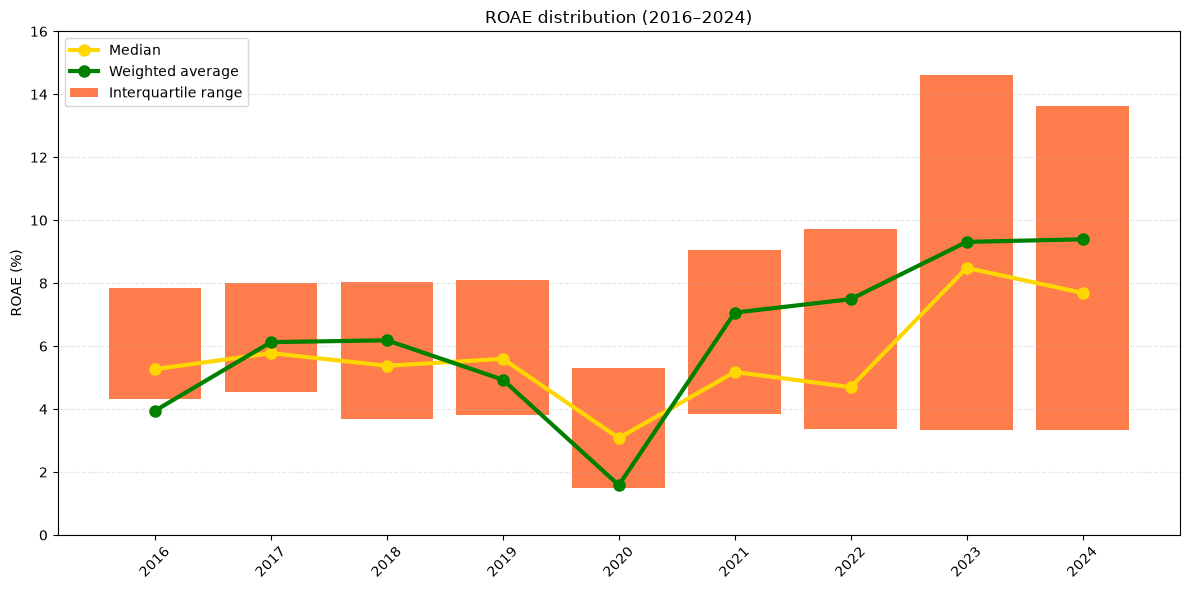


Chart saved to roae_distribution.png


In [ ]:
#=== ROAE DISTRIBUTION GRAPH ===#

years = list(range(2016, 2025))
roae_cols = {year: f"Return on average equity (ROAE) {year}" for year in years}

median_vals = []
weighted_avg_vals = []
q1_vals = []
q3_vals = []

weight_col = "Total assets EUR 2024"
weights = df[weight_col].dropna()

for year in years:
    col = roae_cols[year]
    data = df[col]

    aligned = pd.concat([data, weights], axis=1, join="inner").dropna()

    valid = aligned.iloc[:, 0]
    valid_weights = aligned.iloc[:, 1]

    w_avg = np.average(valid, weights=valid_weights)
    weighted_avg_vals.append(w_avg)

    median_vals.append(valid.median())
    q1_vals.append(np.percentile(valid, 25))
    q3_vals.append(np.percentile(valid, 75))

plt.figure(figsize=(12, 6))
x = np.arange(len(years))

plt.bar(x, np.array(q3_vals) - np.array(q1_vals), bottom=q1_vals, color="orangered", alpha=0.7, label="Interquartile range")
plt.plot(x, median_vals, color="gold", marker="o", markersize=8, linewidth=3, label="Median")
plt.plot(x, weighted_avg_vals, color="green", marker="o", markersize=8, linewidth=3, label="Weighted average")

plt.xticks(x, [str(y) for y in years], rotation=45)
plt.ylabel("ROAE (%)")
plt.title("ROAE distribution (2016–2024)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.ylim(0, 16)

plt.show()



## 5. Cost to Income Ratio (2006–2024)

Dual dashboard:
- **Left:** time series evolution (mean, median, IQR band).
- **Right:** cross sectional comparison by bank size (SI vs. quartile-based groups) for 2018 vs. 2024.

**Preprocessing:** banks with fewer than 5 valid years are dropped; CTI values above 150% are winsorized.
Bank size categories: Significant Institutions (TA > €30bn) and quartile based groups on the rest.

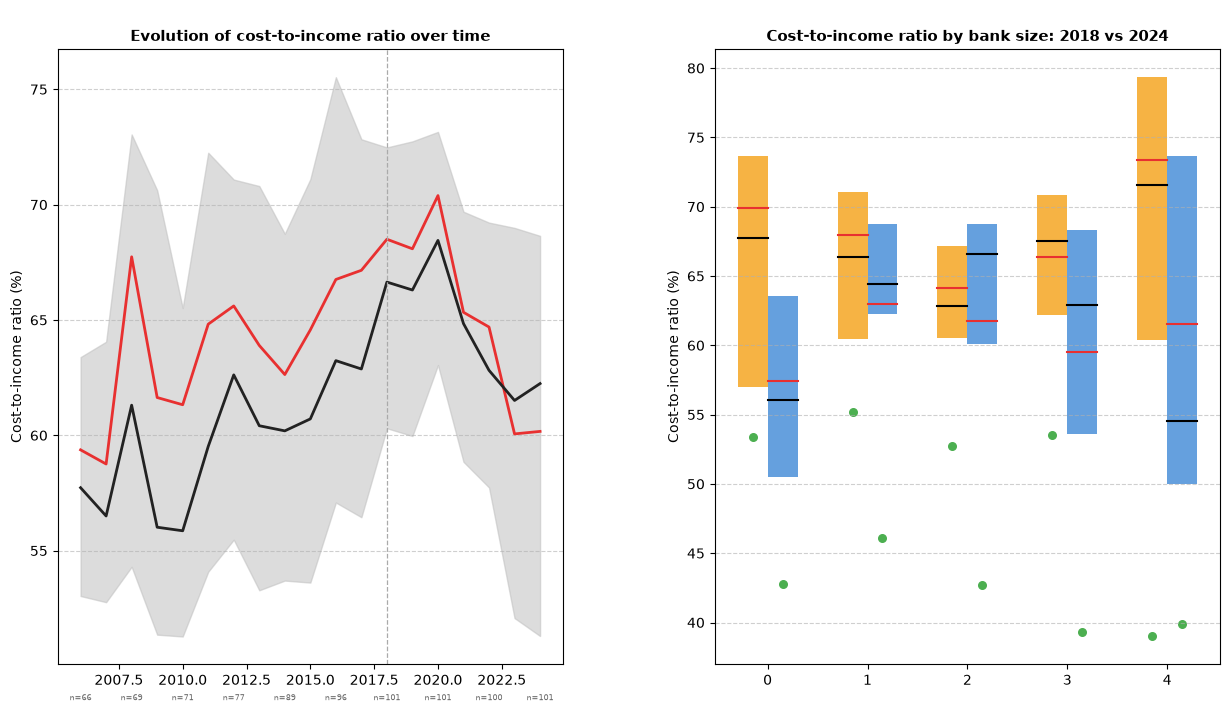

In [52]:
df.columns = df.columns.str.strip()

cti_cols = [c for c in df.columns if 'Cost-to-income' in c]
ta_cols  = [c for c in df.columns if 'Total assets'   in c]

n_valid_years = df[cti_cols].notna().sum(axis=1)
df = df[n_valid_years >= 5].copy()

for col in cti_cols:
    df.loc[df[col] > 150, col] = 150

YEARS = list(range(2006, 2025))

def get_size_stats(year):
    cti_col = f'Cost-to-income (Efficiency) ratio {year}'
    ta_col  = f'Total assets EUR {year}'

    sub = df[[cti_col, ta_col]].dropna()
    sub = sub[sub[cti_col] > 0]

    si = sub[sub[ta_col] > 30e9][cti_col]
    non_si = sub[sub[ta_col] <= 30e9]

    if len(non_si) == 0:
        q25, q50, q75 = 0, 0, 0
    else:
        q75 = non_si[ta_col].quantile(0.75)
        q50 = non_si[ta_col].quantile(0.50)
        q25 = non_si[ta_col].quantile(0.25)

    large = non_si[non_si[ta_col] > q75][cti_col]
    medium = non_si[(non_si[ta_col] > q50) & (non_si[ta_col] <= q75)][cti_col]
    small = non_si[(non_si[ta_col] > q25) & (non_si[ta_col] <= q50)][cti_col]
    very_small = non_si[non_si[ta_col] <= q25][cti_col]

    result = {}
    for label, vals in [('SI', si), ('Large', large), ('Medium', medium),
                        ('Small', small), ('Very small', very_small)]:
        if len(vals) > 0:
            result[label] = dict(
                mean = vals.mean(),
                median = vals.median(),
                q25 = vals.quantile(0.25),
                q75 = vals.quantile(0.75),
                p5 = vals.quantile(0.05),
            )
        else:
            result[label] = dict(mean=np.nan, median=np.nan, q25=np.nan, q75=np.nan, p5=np.nan)
    return result

ts = {}
for yr in YEARS:
    cti_col = f'Cost-to-income (Efficiency) ratio {yr}'
    vals = df[cti_col].dropna()
    vals = vals[vals > 0]

    ts[yr] = dict(
        mean = vals.mean(),
        median = vals.median(),
        q25 = vals.quantile(0.25),
        q75 = vals.quantile(0.75),
        n = len(vals),
    )

C_MEAN   = '#E83030'
C_MEDIAN = '#222222'
C_IQR_BG = '#C0C0C0'
C_DOT    = '#4CAF50'

fig = plt.figure(figsize=(15, 8.5))
fig.patch.set_facecolor('white')

from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 2, figure=fig,
              height_ratios=[0.06, 0.94],
              hspace=0.0, wspace=0.30)

ax_hdr = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

ax_hdr.set_facecolor('#1A4F8A')
ax_hdr.set_xlim(0, 1)
ax_hdr.set_ylim(0, 1)
ax_hdr.axis('off')

ax_hdr.text(0.01, 0.5, 'LM Applied Data Science for Banking and Finance',
            fontsize=10, fontweight='bold', color='white', va='center', ha='left')
ax_hdr.text(0.99, 0.5, 'Università Cattolica del Sacro Cuore',
            fontsize=10, fontweight='bold', color='white', va='center', ha='right')

yrs = list(ts.keys())
means = [ts[y]['mean'] for y in yrs]
meds = [ts[y]['median'] for y in yrs]
q25s = [ts[y]['q25'] for y in yrs]
q75s = [ts[y]['q75'] for y in yrs]
ns = [ts[y]['n'] for y in yrs]

ax1.fill_between(yrs, q25s, q75s, color=C_IQR_BG, alpha=0.55)
ax1.plot(yrs, means, color=C_MEAN, linewidth=2.0)
ax1.plot(yrs, meds,  color=C_MEDIAN, linewidth=2.0)
ax1.axvline(x=2018, color='#AAAAAA', linestyle='--', linewidth=0.9)

for yr, n in zip(yrs, ns):
    if yr % 2 == 0:
        ax1.text(yr, min(q25s) - 2.5, f'n={n}', fontsize=5.5,
                 ha='center', va='top', color='#666666')

ax1.set_title('Evolution of cost-to-income ratio over time', fontsize=11, fontweight='bold')
ax1.set_ylabel('Cost-to-income ratio (%)')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

categories = ['SI\nTA>30bn', 'Large', 'Medium', 'Small', 'Very small']
cat_keys   = ['SI', 'Large', 'Medium', 'Small', 'Very small']

stats_2018 = get_size_stats(2018)
stats_2024 = get_size_stats(2024)

BAR_W = 0.30
x = np.arange(len(cat_keys))

for yr, stats, color, offset in [('2018', stats_2018, '#F5A623', -BAR_W/2),
                                 ('2024', stats_2024, '#4A90D9', BAR_W/2)]:
    for i, key in enumerate(cat_keys):
        s = stats[key]
        xpos = x[i] + offset
        if not np.isnan(s['q25']):
            ax2.bar(xpos, s['q75'] - s['q25'], bottom=s['q25'], width=BAR_W, color=color, alpha=0.85)
            ax2.plot([xpos - BAR_W/2, xpos + BAR_W/2], [s['median'], s['median']], color='black')
            ax2.plot([xpos - BAR_W/2, xpos + BAR_W/2], [s['mean'], s['mean']], color=C_MEAN)
            ax2.scatter(xpos, s['p5'], color=C_DOT, s=30)

ax2.set_title('Cost-to-income ratio by bank size: 2018 vs 2024', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cost-to-income ratio (%)')
ax2.grid(axis='y', linestyle='--', alpha=0.6)


## 6. Market Concentration — Top 5 Banks (2006–2024)

Share of total sample assets held by the five largest banks (by 2024 Total Assets), tracked over time.

Top 5 banks in 2024 are:
                         Company name Latin alphabet  Total assets EUR 2024
0                                        BNP PARIBAS           2.704908e+12
1  DEUTSCHER SPARKASSEN-UND GIROVERBAND EV (COMBI...           2.536923e+12
2                                 BANCO SANTANDER SA           1.837081e+12
3                                   SOCIETE GENERALE           1.573545e+12
4                                   DEUTSCHE BANK AG           1.387177e+12
 Year  Top5 Share (%)
 2006           53.64
 2007           62.57
 2008           60.70
 2009           59.82
 2010           59.93
 2011           59.62
 2012           59.59
 2013           58.37
 2014           59.29
 2015           59.04
 2016           58.53
 2017           54.87
 2018           54.85
 2019           54.45
 2020           53.58
 2021           53.46
 2022           54.24
 2023           54.12
 2024           54.31


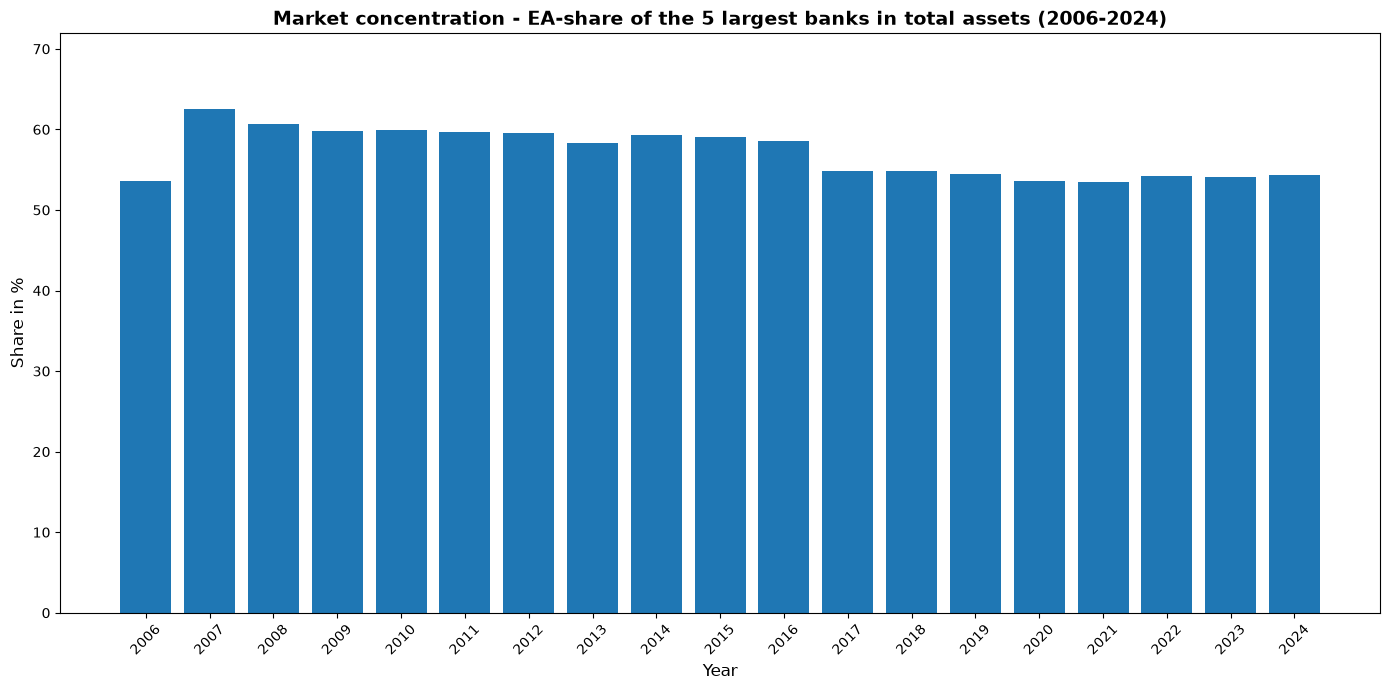

In [ ]:
bank_col = 'Company name Latin alphabet'
years = list(range(2006, 2025))
asset_cols = [f'Total assets EUR {year}' for year in years]
col_2024 = 'Total assets EUR 2024'

existing_asset_cols = [col for col in asset_cols if col in df.columns]

df_filtered = df[df[col_2024].notna()].copy()

top5 = df_filtered.sort_values(by=col_2024, ascending=False).head(5).copy()
print(f"Top 5 banks in 2024 are:\n{top5[[bank_col, col_2024]]}")

share_data = []
for col in existing_asset_cols:
    year = int(col.split()[-1])
    top5_sum = top5[col].sum(skipna=True)
    total_sum = df_filtered[col].sum(skipna=True)
    share_pct = (top5_sum / total_sum * 100) if total_sum > 0 else np.nan

    share_data.append({
        'Year': year,
        'Top5 Share (%)': round(share_pct, 2)
    })

share_df = pd.DataFrame(share_data).sort_values('Year')
print(share_df.to_string(index=False))

plt.figure(figsize=(14, 7))
plt.bar(share_df['Year'], share_df['Top5 Share (%)'])
plt.title('Market concentration - EA-share of the 5 largest banks in total assets (2006-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Share in %', fontsize=12)
plt.xticks(share_df['Year'], rotation=45)
plt.ylim(0, max(share_df['Top5 Share (%)'].dropna()) * 1.15)
plt.tight_layout()
plt.show()
